# Project 5 — Notebook 16: Site Risk Profiling
### Site Complexity Classification · Risk Score Construction · Zone Pareto

---

| | |
|---|---|
| **Scope** | NCR (Region 3) · All reactive tickets (Priority 1–3) · Site-level analysis |
| **Feeds from** | `output/cleaned_fault_ticket.csv` · NB13–14 (high-risk cities) |
| **Audience** | Operations Leadership / Area Heads / Team Leads |

---

**Questions this notebook answers:**
1. How complex is each site — and does higher complexity correlate with worse SLA and MTTR?
2. Which sites are chronically underperforming on fault frequency, MTTR, and SLA breach rate?
3. Where should area heads and team leads focus preventive maintenance effort?
4. Do the extreme MTTR outliers in Zone 1 (433h, 245h) reflect site complexity or other factors?

---

**Data scope notes:**
- `Field_Lead_ID = 'Unknown'` on ~14,075 tickets — these are Auto-Restored and NOC-Remote tickets
  where no field engineer was dispatched. Expected behavior, not a data gap.
- Site risk scoring uses **Field_Dispatch_Restored** tickets only for MTTR and field time metrics,
  since only dispatched tickets reflect actual field resolution performance.
- Timestamp-clean tickets (`Timestamp_Integrity = True`) used for phase-time breakdowns.

## 1. Setup

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display, Markdown
%matplotlib inline

os.chdir(os.path.join('..', '..'))
if os.path.abspath(os.getcwd()) not in sys.path:
    sys.path.insert(0, os.path.abspath(os.getcwd()))

from config import ZONE_ORDER, ZONE_PALETTE
from src.visualization.common_plots import plot_heatmap

df      = pd.read_csv('output/cleaned_fault_ticket.csv')
df_zone = df[(df['ZONE'].isin(ZONE_ORDER)) & (df['Priority'] < 4)].copy()
clean   = df_zone[df_zone['Timestamp_Integrity']].copy()

# Field-dispatch only (has engineer, field resolution time)
df_fd   = df_zone[df_zone['Resolution_Path'] == 'Field_Dispatch_Restored'].copy()
clean_fd = clean[clean['Resolution_Path'] == 'Field_Dispatch_Restored'].copy()

# Minimum site ticket threshold for reliable scoring
MIN_SITE_TICKETS = 10

print(f"✅ Reactive tickets (P1-P3): {len(df_zone):,}")
print(f"   Field-dispatch tickets:   {len(df_fd):,}  ({len(df_fd)/len(df_zone)*100:.1f}%)")
print(f"   NOC-Remote + Auto:        {len(df_zone)-len(df_fd):,}  (Unknown Field_Lead_ID — expected)")
print(f"   Timestamp-clean FD:       {len(clean_fd):,}")
print(f"   Unique sites (all):       {df_zone['SiteName'].nunique():,}")
print(f"   Sites ≥{MIN_SITE_TICKETS} tickets:        "
      f"{(df_zone.groupby('SiteName').size() >= MIN_SITE_TICKETS).sum():,}")

✅ Reactive tickets (P1-P3): 36,907
   Field-dispatch tickets:   22,822  (61.8%)
   NOC-Remote + Auto:        14,085  (Unknown Field_Lead_ID — expected)
   Timestamp-clean FD:       21,945
   Unique sites (all):       4,741
   Sites ≥10 tickets:        1,025


## 2. Site Complexity Classification

> Site complexity is derived from two dimensions:
> - **NE type count** — number of unique NEType values at the site (reflects infrastructure diversity)
> - **Core/IP infra presence** — any NE_Category of 'Core Network' or 'IP/Network Infra'
>   automatically classifies the site as High regardless of NE count
>
> **Complexity tiers (operationally-informed, data-validated):**
> - **Low:** 1–2 NE types · simple BTS or transport-only sites
> - **Medium:** 3–5 NE types · mixed access + transmission
> - **High:** ≥6 NE types **or** Core/IP infrastructure present
>
> These bands align with operational intuition (BTS vs mixed vs core infrastructure)
> and are validated against the data distribution (median NE count = 2, max = 20).

In [2]:
CORE_IP_CATS = ['Core Network', 'IP/Network Infra', 'IP Network Infra']

# Build site complexity table
site_ne = (df_zone.groupby('SiteName')
    .agg(
        NE_Count    = ('NEType',       'nunique'),
        Has_Core_IP = ('NE_Category',  lambda x: x.isin(CORE_IP_CATS).any()),
        ZONE        = ('ZONE',          lambda x: x.mode()[0]),
        CITY        = ('CITY',          lambda x: x.mode()[0]),
    )
    .reset_index()
)

def classify_complexity(row):
    if row['Has_Core_IP']:      return 'High'
    if row['NE_Count'] >= 6:    return 'High'
    if row['NE_Count'] >= 3:    return 'Medium'
    return 'Low'

site_ne['Complexity'] = site_ne.apply(classify_complexity, axis=1)

# Distribution
tier_order = ['Low', 'Medium', 'High']
tier_counts = site_ne['Complexity'].value_counts().reindex(tier_order)
print("Complexity tier distribution:")
for tier in tier_order:
    n = tier_counts[tier]
    print(f"  {tier:<8}: {n:>5,} sites  ({n/len(site_ne)*100:.1f}%)")

print(f"\nNE count distribution:")
print(f"  min:{site_ne['NE_Count'].min()}  median:{site_ne['NE_Count'].median():.0f}  "
      f"mean:{site_ne['NE_Count'].mean():.1f}  "
      f"p80:{site_ne['NE_Count'].quantile(0.8):.0f}  "
      f"p95:{site_ne['NE_Count'].quantile(0.95):.0f}  "
      f"max:{site_ne['NE_Count'].max()}")
print(f"  Sites with Core/IP: {site_ne['Has_Core_IP'].sum():,}")
print(f"  Sites with NE_Count ≥ 6: {(site_ne['NE_Count'] >= 6).sum():,}")

# Join to tickets for cross-tab
df_cx = df_zone.merge(site_ne[['SiteName','Complexity','NE_Count','Has_Core_IP']],
                       on='SiteName', how='left')

# Cross-tab: complexity vs performance
print("\nComplexity vs performance (all reactive tickets):")
print(f"  {'Tier':<8} {'Sites':>6} {'Tickets':>8} {'SLA%':>7} {'MTTR':>7} {'Density':>8}")
for tier in tier_order:
    t = df_cx[df_cx['Complexity'] == tier]
    sites = t['SiteName'].nunique()
    density = len(t) / sites if sites > 0 else 0
    print(f"  {tier:<8} {sites:>6,} {len(t):>8,} "
          f"{t['SLA_Compliant'].mean()*100:>6.1f}% "
          f"{t['OUTAGEDURATION'].mean():>6.0f}h "
          f"{density:>8.1f}")

Complexity tier distribution:
  Low     : 2,883 sites  (60.8%)
  Medium  : 1,321 sites  (27.9%)
  High    :   537 sites  (11.3%)

NE count distribution:
  min:1  median:2  mean:2.3  p80:3  p95:5  max:20
  Sites with Core/IP: 482
  Sites with NE_Count ≥ 6: 107

Complexity vs performance (all reactive tickets):
  Tier      Sites  Tickets    SLA%    MTTR  Density
  Low       2,883   12,394   83.0%     46h      4.3
  Medium    1,321   14,021   81.3%     67h     10.6
  High        537   10,492   82.2%     60h     19.5


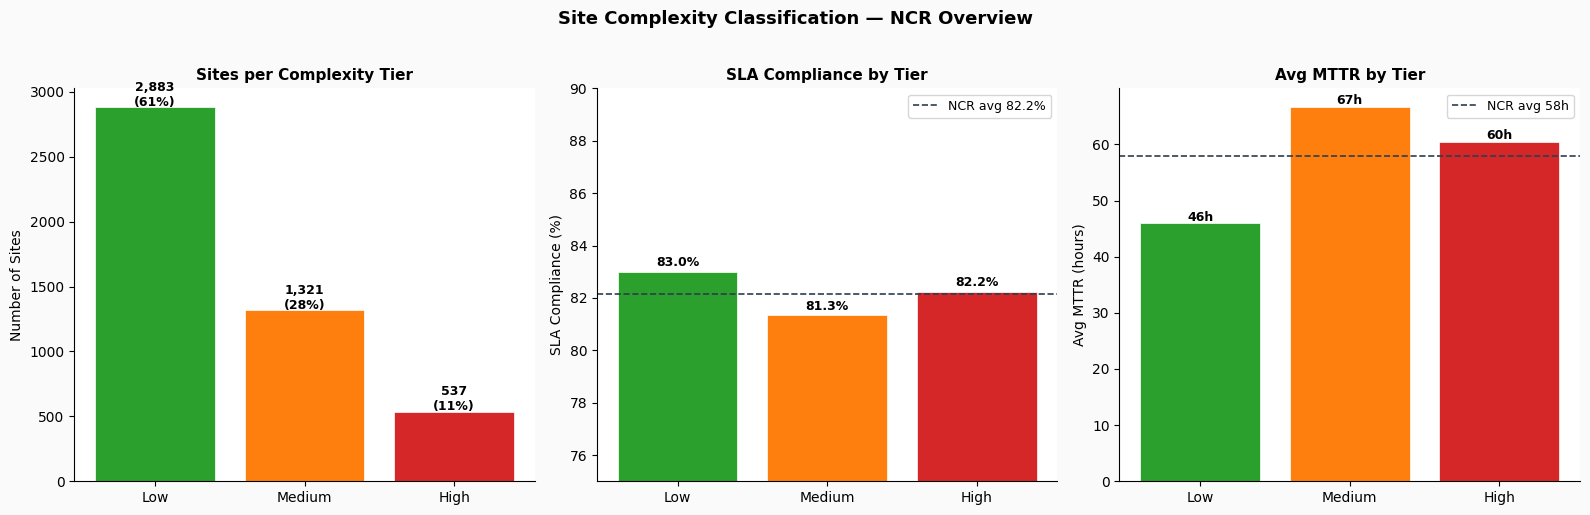

In [3]:
# Visualise: complexity tier distribution + performance cross-tab
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#fafafa')
fig.suptitle('Site Complexity Classification — NCR Overview', 
             fontsize=13, fontweight='bold', y=1.02)

TIER_COLORS = {'Low':'#2ca02c', 'Medium':'#ff7f0e', 'High':'#d62728'}

# [Left] Site count by tier
counts = [tier_counts[t] for t in tier_order]
bars = axes[0].bar(tier_order, counts,
                    color=[TIER_COLORS[t] for t in tier_order],
                    edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                  f'{val:,}\n({val/len(site_ne)*100:.0f}%)',
                  ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Sites per Complexity Tier', fontsize=11, fontweight='bold', pad=6)
axes[0].set_ylabel('Number of Sites', fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# [Middle] SLA by tier
sla_vals = [df_cx[df_cx['Complexity']==t]['SLA_Compliant'].mean()*100 for t in tier_order]
ncr_sla  = df_zone['SLA_Compliant'].mean() * 100
bars2 = axes[1].bar(tier_order, sla_vals,
                     color=[TIER_COLORS[t] for t in tier_order],
                     edgecolor='white', linewidth=0.5)
axes[1].axhline(ncr_sla, color='#2c3e50', linestyle='--', linewidth=1.2,
                 label=f'NCR avg {ncr_sla:.1f}%')
for bar, val in zip(bars2, sla_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                  f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_ylim(75, 90)
axes[1].set_title('SLA Compliance by Tier', fontsize=11, fontweight='bold', pad=6)
axes[1].set_ylabel('SLA Compliance (%)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# [Right] MTTR by tier
mttr_vals = [df_cx[df_cx['Complexity']==t]['OUTAGEDURATION'].mean() for t in tier_order]
ncr_mttr  = df_zone['OUTAGEDURATION'].mean()
bars3 = axes[2].bar(tier_order, mttr_vals,
                     color=[TIER_COLORS[t] for t in tier_order],
                     edgecolor='white', linewidth=0.5)
axes[2].axhline(ncr_mttr, color='#2c3e50', linestyle='--', linewidth=1.2,
                 label=f'NCR avg {ncr_mttr:.0f}h')
for bar, val in zip(bars3, mttr_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                  f'{val:.0f}h', ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Avg MTTR by Tier', fontsize=11, fontweight='bold', pad=6)
axes[2].set_ylabel('Avg MTTR (hours)', fontsize=10)
axes[2].legend(fontsize=9)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('reports/figures/project5_ncr/16_complexity_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Site Risk Score Construction

> Each site is scored on four dimensions, then ranked within its zone:
>
> | Dimension | Weight | Rationale |
> |-----------|--------|-----------|
> | Fault frequency (tickets/month) | 30% | Volume of recurring faults — PM priority signal |
> | Avg MTTR (hours) | 30% | Resolution difficulty — measures impact on service |
> | SLA breach rate (%) | 25% | Compliance failure — operational accountability |
> | Complexity tier | 15% | Structural difficulty — context for expected performance |
>
> Scores are percentile ranks within zone (0–100, higher = worse).
> Sites with < 10 tickets are included but flagged — low volume means less reliable rank.
> Only **Field_Dispatch_Restored** tickets used for MTTR and SLA — these are the tickets
> that actually reached the field phase and reflect genuine field resolution performance.

In [4]:
# Build site-level stats (field-dispatch tickets for MTTR/SLA,
# all reactive tickets for fault frequency)
date_range_months = (pd.to_datetime(df_zone['REPORTDATE']).max() -
                     pd.to_datetime(df_zone['REPORTDATE']).min()).days / 30.44

site_vol = (df_zone.groupby(['ZONE','SiteName'])
    .agg(All_Tickets=('SLA_Compliant','count'))
    .reset_index())

site_fd = (df_fd.groupby(['ZONE','SiteName'])
    .agg(
        FD_Tickets    = ('SLA_Compliant', 'count'),
        SLA_pct       = ('SLA_Compliant', 'mean'),
        Avg_MTTR      = ('OUTAGEDURATION','mean'),
    )
    .reset_index())
site_fd['SLA_pct']     *= 100
site_fd['Breach_Rate']  = 100 - site_fd['SLA_pct']

# Merge volume + FD stats + complexity
site_risk = (site_vol
    .merge(site_fd, on=['ZONE','SiteName'], how='left')
    .merge(site_ne[['SiteName','Complexity','NE_Count','Has_Core_IP','CITY']],
           on='SiteName', how='left')
)
site_risk['FD_Tickets']    = site_risk['FD_Tickets'].fillna(0)
site_risk['Fault_per_Month'] = site_risk['All_Tickets'] / date_range_months
site_risk['Low_Vol']         = site_risk['All_Tickets'] < MIN_SITE_TICKETS

# Complexity numeric weight
site_risk['Complexity_Score'] = site_risk['Complexity'].map(
    {'Low': 0, 'Medium': 50, 'High': 100}
)

# Percentile rank within zone for each dimension (higher = worse = higher risk)
def pct_rank(series):
    return series.rank(pct=True, na_option='bottom') * 100

for zone in ZONE_ORDER:
    mask = site_risk['ZONE'] == zone
    site_risk.loc[mask, 'Freq_Rank']   = pct_rank(site_risk.loc[mask, 'Fault_per_Month'])
    site_risk.loc[mask, 'MTTR_Rank']   = pct_rank(site_risk.loc[mask, 'Avg_MTTR'])
    site_risk.loc[mask, 'Breach_Rank'] = pct_rank(site_risk.loc[mask, 'Breach_Rate'])

site_risk['Risk_Score'] = (
    site_risk['Freq_Rank']        * 0.30 +
    site_risk['MTTR_Rank']        * 0.30 +
    site_risk['Breach_Rank']      * 0.25 +
    site_risk['Complexity_Score'] * 0.15
)

site_risk = site_risk.sort_values(['ZONE','Risk_Score'], ascending=[True, False])

print(f"Site risk scores computed for {len(site_risk):,} sites")
print(f"Sites with ≥{MIN_SITE_TICKETS} tickets (reliable score): "
      f"{(~site_risk['Low_Vol']).sum():,}")
print(f"\nTop 5 highest-risk sites NCR-wide:")
top5 = site_risk[~site_risk['Low_Vol']].nlargest(5, 'Risk_Score')
for _, r in top5.iterrows():
    print(f"  {r['SiteName']:<45} {r['ZONE']}  "
          f"Score:{r['Risk_Score']:.0f}  "
          f"Tickets:{int(r['All_Tickets'])}  "
          f"MTTR:{r['Avg_MTTR']:.0f}h  "
          f"Breach:{r['Breach_Rate']:.0f}%  "
          f"Complexity:{r['Complexity']}")

Site risk scores computed for 4,741 sites
Sites with ≥10 tickets (reliable score): 1,025

Top 5 highest-risk sites NCR-wide:
  Region3_RIZAL_d34790a1                        ZONE 3  Score:91  Tickets:20  MTTR:58h  Breach:45%  Complexity:High
  Region3_RIZAL_bcd3559d                        ZONE 3  Score:91  Tickets:29  MTTR:60h  Breach:36%  Complexity:High
  Region3_VALENZUELA CITY_5dfa82e0              ZONE 1  Score:90  Tickets:25  MTTR:134h  Breach:46%  Complexity:High
  Region3_RIZAL_16e9c7a5                        ZONE 3  Score:90  Tickets:39  MTTR:38h  Breach:36%  Complexity:High
  Region3_CALOOCAN CITY_260e8b5e                ZONE 1  Score:89  Tickets:130  MTTR:41h  Breach:44%  Complexity:High


## 4. Zone-Level Site Risk Pareto — Top 20 Sites per Zone

> Top 20 highest-risk sites per zone by composite score.
> Bar colour = complexity tier. Stars (★) indicate sites with MTTR > 200h — extreme outliers
> that warrant immediate investigation regardless of overall risk rank.

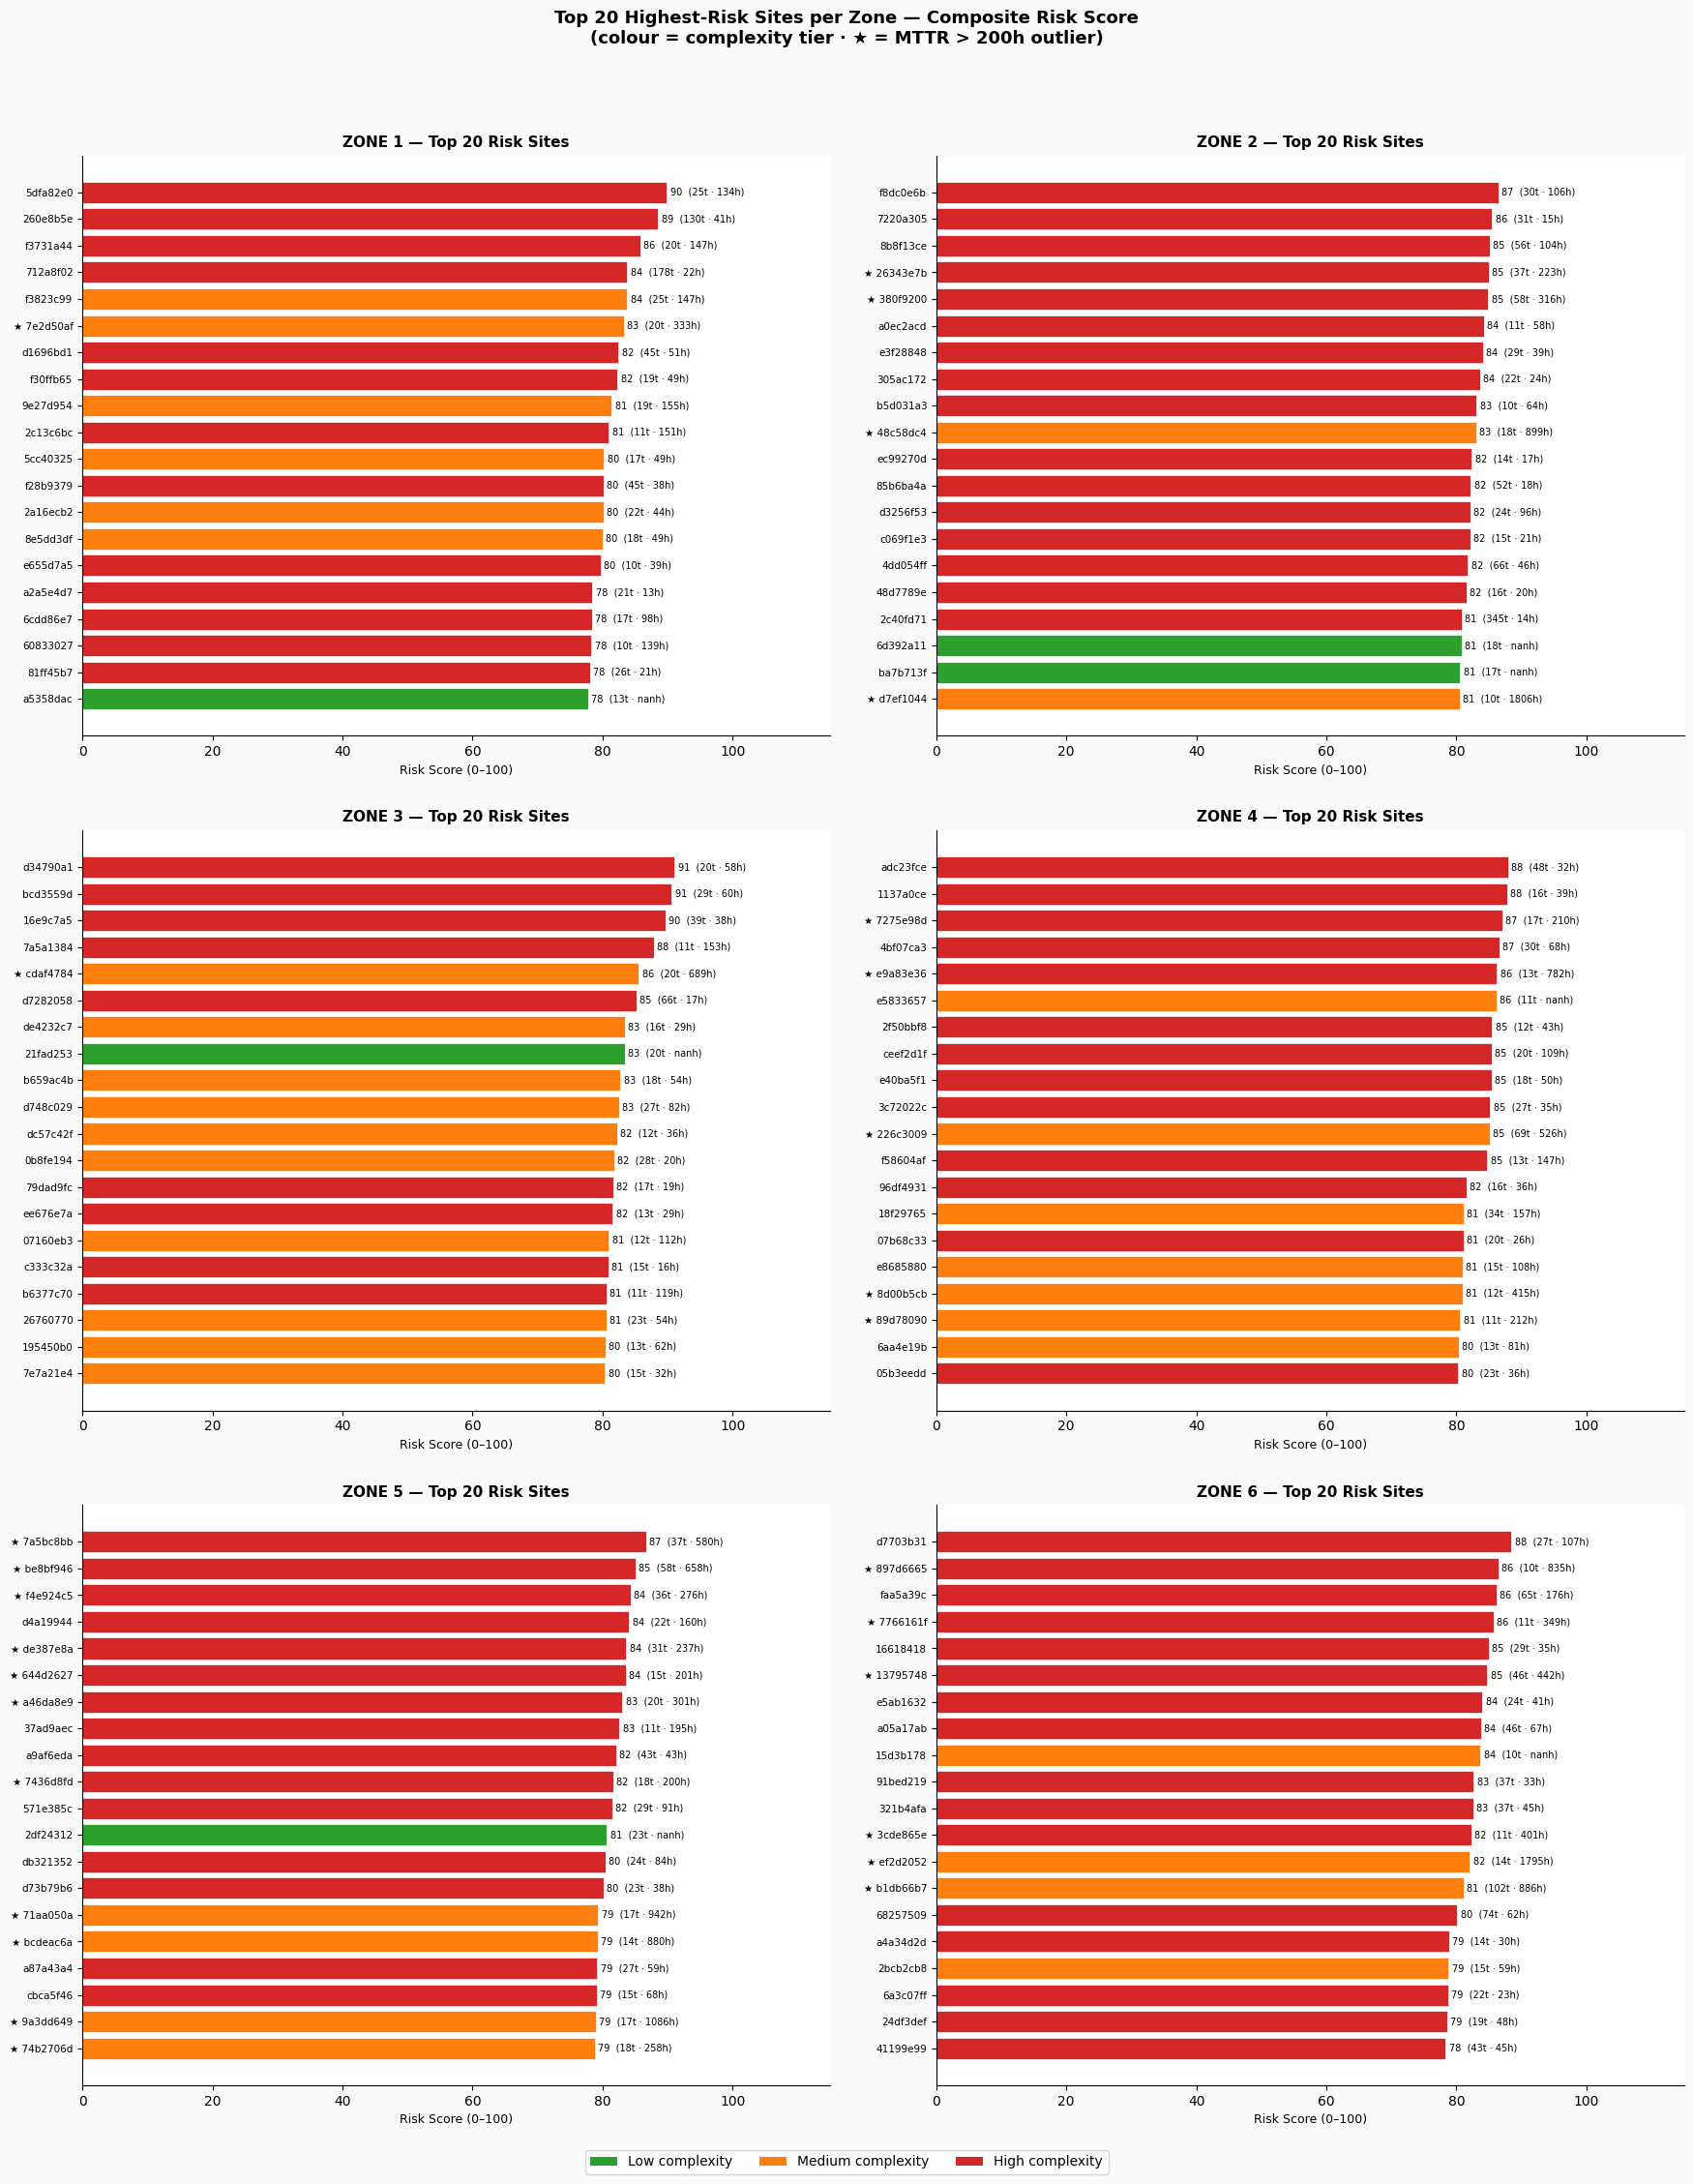

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(18, 22))
fig.patch.set_facecolor('#fafafa')
fig.suptitle('Top 20 Highest-Risk Sites per Zone — Composite Risk Score\n'
             '(colour = complexity tier · ★ = MTTR > 200h outlier)',
             fontsize=13, fontweight='bold', y=1.01)
axes = axes.flatten()

for ax_i, zone in enumerate(ZONE_ORDER):
    ax = axes[ax_i]
    top20 = (site_risk[(site_risk['ZONE'] == zone) & (~site_risk['Low_Vol'])]
             .head(20).copy())
    if top20.empty:
        ax.text(0.5, 0.5, 'No sites with\n≥10 tickets', ha='center', va='center',
                 transform=ax.transAxes)
        ax.set_title(zone)
        continue

    colors = [TIER_COLORS[c] if pd.notna(c) else '#aaaaaa'
              for c in top20['Complexity']]
    # Shorten site name for display
    labels = [s.split('_',2)[-1][:30] if '_' in s else s[:30]
              for s in top20['SiteName']]
    # Add outlier star
    labels = [f"★ {l}" if (r > 200 and pd.notna(r)) else l
              for l, r in zip(labels, top20['Avg_MTTR'])]

    bars = ax.barh(range(len(top20)), top20['Risk_Score'],
                    color=colors, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(top20)))
    ax.set_yticklabels(labels, fontsize=7.5)
    ax.invert_yaxis()

    for bar, score, tickets, mttr in zip(bars, top20['Risk_Score'],
                                          top20['All_Tickets'], top20['Avg_MTTR']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{score:.0f}  ({int(tickets)}t · {mttr:.0f}h)',
                 va='center', fontsize=7)

    ax.set_title(f'{zone} — Top 20 Risk Sites', fontsize=11, fontweight='bold', pad=6)
    ax.set_xlabel('Risk Score (0–100)', fontsize=9)
    ax.set_xlim(0, 115)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend
legend_els = [mpatches.Patch(facecolor=TIER_COLORS[t], label=f'{t} complexity')
               for t in tier_order]
fig.legend(handles=legend_els, loc='lower center', ncol=3,
            fontsize=10, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(pad=2.5)
plt.savefig('reports/figures/project5_ncr/16_site_risk_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. MTTR Outlier Investigation — Zone 1 Extreme Sites

> Two Zone 1 sites show extreme MTTR outliers (433h and 245h) identified in the
> Project 1 snapshot. These sites single-handedly distort Zone 1's average MTTR.
> This section investigates whether the extreme MTTR is driven by site complexity,
> a specific RFO type, or a recurring unresolved fault.

In [6]:
# Zone 1 sites sorted by MTTR — identify the extreme outliers
z1_sites = site_risk[site_risk['ZONE'] == 'ZONE 1'].sort_values('Avg_MTTR', ascending=False)

print("Zone 1 — top 10 sites by avg MTTR (field-dispatch tickets):")
print(f"  {'Site':<45} {'Tickets':>7} {'MTTR':>8} {'Breach%':>8} {'Complexity':<10} {'City'}")
for _, r in z1_sites.head(10).iterrows():
    name = r['SiteName'].split('_',2)[-1] if '_' in r['SiteName'] else r['SiteName']
    breach = f"{r['Breach_Rate']:.0f}%" if pd.notna(r['Breach_Rate']) else 'N/A'
    print(f"  {name:<45} {int(r['All_Tickets']):>7} "
          f"{r['Avg_MTTR']:>7.0f}h {breach:>8}  "
          f"{r['Complexity']:<10} {r['CITY']}")

# Deep dive on top 2 outlier sites
print("\n--- Deep dive: top 2 MTTR outlier sites ---")
top2_sites = z1_sites.head(2)['SiteName'].tolist()
for site in top2_sites:
    site_tix = df_zone[df_zone['SiteName'] == site]
    print(f"\n{site}")
    print(f"  Total tickets: {len(site_tix)}")
    print(f"  MTTR range: {site_tix['OUTAGEDURATION'].min():.0f}h – "
          f"{site_tix['OUTAGEDURATION'].max():.0f}h")
    print(f"  Resolution paths: {site_tix['Resolution_Path'].value_counts().to_dict()}")
    print(f"  Top RFOs:")
    rfo_counts = site_tix['Standardized RFO'].value_counts().head(5)
    for rfo, cnt in rfo_counts.items():
        rfo_mttr = site_tix[site_tix['Standardized RFO']==rfo]['OUTAGEDURATION'].mean()
        print(f"    {rfo:<45} {cnt:>3} tickets  avg MTTR: {rfo_mttr:.0f}h")
    print(f"  Complexity: {site_ne[site_ne['SiteName']==site]['Complexity'].values}")
    print(f"  NE types: {site_ne[site_ne['SiteName']==site]['NE_Count'].values}")

Zone 1 — top 10 sites by avg MTTR (field-dispatch tickets):
  Site                                          Tickets     MTTR  Breach% Complexity City
  a2c4633b                                            6    3002h     100%  Low        VALENZUELA CITY
  edb7ecfd                                            3    2786h     100%  Low        VALENZUELA CITY
  2404552c                                            2    2454h     100%  Low        CALOOCAN CITY
  8f5c8c76                                            6    1949h      50%  Medium     CALOOCAN CITY
  4d3eccf4                                            5    1852h      40%  Low        CALOOCAN CITY
  c3428183                                            5    1321h      50%  Low        CALOOCAN CITY
  83f393fd                                            9    1113h      33%  Medium     VALENZUELA CITY
  19c66d06                                            8     800h      33%  Low        CALOOCAN CITY
  8677b5d8                                  

## 6. Field Engineer Load Distribution

> Field engineer analysis uses **Field_Dispatch_Restored** tickets only.
> `Field_Lead_ID = 'Unknown'` are system-generated tickets with no engineer dispatched
> — expected behavior, excluded from load analysis.
>
> **Field Operations** tickets are identified via `WOOwnerGroup == 'Field Operations'`
> (the normalised category set by the pipeline). Engineers are then filtered to those
> whose **home zone matches the ticket zone** — cross-zone assignments (e.g. a fiber
> cut whose root cause sits in an adjacent zone) are excluded from per-zone load counts
> to avoid inflating or distorting zone engineer headcounts.
>
> An activity threshold of **≥ 100 tickets** is applied as a secondary filter to remove
> incidental assignees — engineers who appear in the data only because of occasional
> cross-zone support, not as regular members of the zone team.
>
> Lorenz curves and Gini coefficients show load inequality within each zone.
> 0 = perfectly equal · 1 = all load on one engineer.

In [7]:
# Step 1 — Field Operations WOs only (WOOwnerGroup normalised by pipeline)
FIELD_ENG_GROUPS = ['Field Operations']

fe_all = df_fd[df_fd['Field_Lead_ID'] != 'Unknown'].copy()

if 'WOOwnerGroup' in fe_all.columns:
    fe_df = fe_all[fe_all['WOOwnerGroup'].isin(FIELD_ENG_GROUPS)].copy()
    non_fe = fe_all[~fe_all['WOOwnerGroup'].isin(FIELD_ENG_GROUPS)]
    print('FD tickets with Field_Lead_ID attributed:')
    print(f'  Total:                    {len(fe_all):,}')
    print(f'  Field Operations:         {len(fe_df):,}  ({len(fe_df)/len(fe_all)*100:.1f}%)')
    print(f'  Other groups (see NB17):  {len(non_fe):,}  ({len(non_fe)/len(fe_all)*100:.1f}%)')
else:
    fe_df = fe_all
    print('WOOwnerGroup not in data — re-run pipeline.')

# Step 2 — Zone alignment filter
# Keep only engineers whose modal (home) zone matches the ticket zone.
# Cross-zone assignments (e.g. fiber cuts with root cause in adjacent zone)
# are valid operationally but should not inflate a zone's engineer headcount.
eng_home_zone = (fe_df.groupby('Field_Lead_ID')['ZONE']
    .agg(lambda x: x.mode()[0])
    .rename('Home_Zone')
    .reset_index())
fe_df = fe_df.merge(eng_home_zone, on='Field_Lead_ID', how='left')
fe_df = fe_df[fe_df['ZONE'] == fe_df['Home_Zone']].copy()

# Step 3 — Activity threshold: ≥ 100 tickets in home zone
# Removes incidental assignees (cross-zone support, one-off covers)
# who are not regular members of the zone team.
MIN_TICKETS = 100
zone_counts = fe_df.groupby(['ZONE','Field_Lead_ID']).size().reset_index(name='Ticket_Count')
active_engs = zone_counts[zone_counts['Ticket_Count'] >= MIN_TICKETS][['ZONE','Field_Lead_ID']]
fe_df = fe_df.merge(active_engs, on=['ZONE','Field_Lead_ID'], how='inner')

print(f'\nAfter zone-alignment + activity threshold (≥{MIN_TICKETS} tickets):')
for zone in ZONE_ORDER:
    z = fe_df[fe_df['ZONE'] == zone]
    n_engs = z['Field_Lead_ID'].nunique()
    print(f'  {zone}: {n_engs:>3} engineers  {len(z):,} tickets')

# Per-engineer stats for Lorenz/Gini
fe_stats = (fe_df.groupby(['ZONE','Field_Lead_ID'])
    .agg(Tickets=('SLA_Compliant','count'),
         SLA_pct=('SLA_Compliant','mean'),
         Sites=('SiteName','nunique'),
         Avg_MTTR=('OUTAGEDURATION','mean'))
    .reset_index())
fe_stats['SLA_pct'] *= 100

FD tickets with Field_Lead_ID attributed:
  Total:                    22,822
  Field Operations:         19,787  (86.7%)
  Other groups (see NB17):  3,035  (13.3%)

After zone-alignment + activity threshold (≥100 tickets):
  ZONE 1:   8 engineers  2,139 tickets
  ZONE 2:  15 engineers  3,274 tickets
  ZONE 3:  10 engineers  2,919 tickets
  ZONE 4:  15 engineers  3,400 tickets
  ZONE 5:  19 engineers  3,984 tickets
  ZONE 6:   8 engineers  1,987 tickets


Field engineer load summary (zone-aligned, ≥100 tickets per engineer):
  Total active engineers: 75

  Zone      Engrs   Med_t   Max_t    Gini  Med_sites  Avg_SLA
  ZONE 1        8     266     407   0.206         60    78.2%
  ZONE 2       15     203     397   0.226         58    81.3%
  ZONE 3       10     282     547   0.229         72    79.2%
  ZONE 4       15     239     319   0.141         61    77.7%
  ZONE 5       19     215     338   0.187         50    70.4%
  ZONE 6        8     246     379   0.165         62    72.6%

  Engineers with site count > 2× zone median (endorsement bottleneck risk):
  No engineers exceed 2× zone median — load is well-distributed


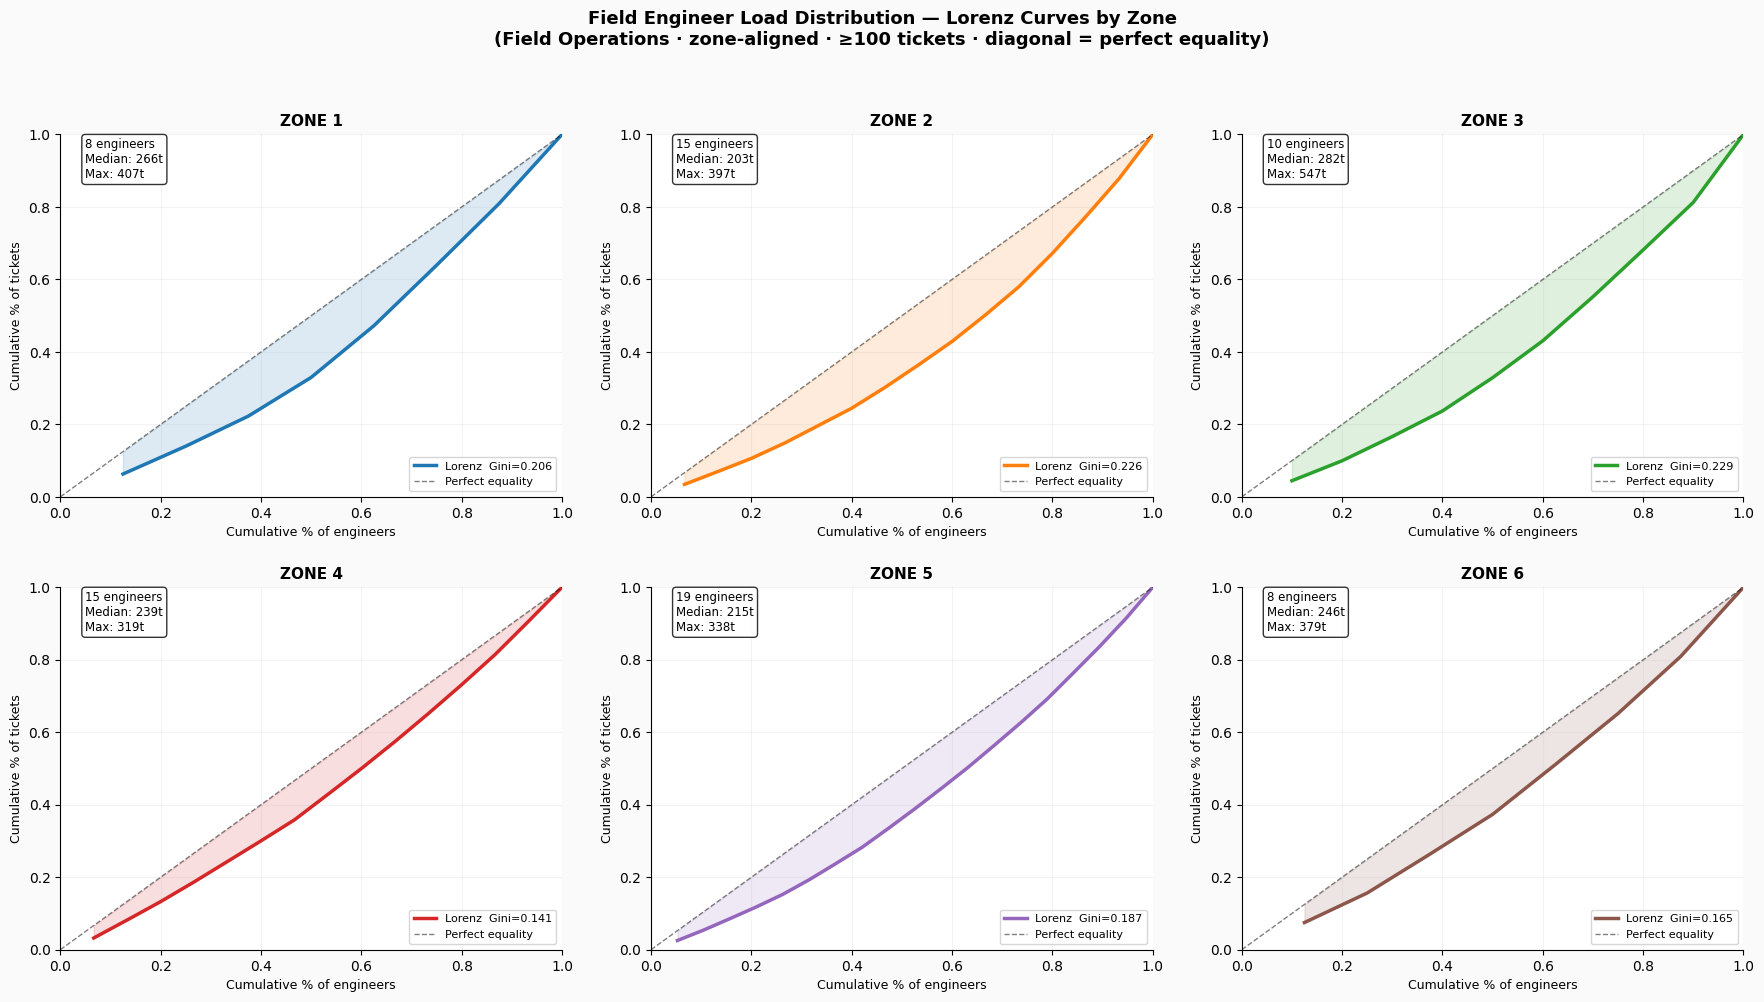

In [8]:
# ── Gini coefficient computation ────────────────────────────────────────
def gini(arr):
    arr = np.sort(arr.astype(float))
    n = len(arr)
    if n < 2 or arr.sum() == 0: return 0.0
    return (2 * np.sum(np.arange(1, n+1) * arr) / (n * arr.sum())) - (n+1)/n

print(f"Field engineer load summary (zone-aligned, ≥{MIN_TICKETS} tickets per engineer):")
print(f"  Total active engineers: {fe_stats['Field_Lead_ID'].nunique() if 'Field_Lead_ID' in fe_stats.columns else df_fe['Field_Lead_ID'].nunique()}")
print(f"\n  {'Zone':<8} {'Engrs':>6} {'Med_t':>7} {'Max_t':>7} {'Gini':>7} "
      f"{'Med_sites':>10} {'Avg_SLA':>8}")
for zone in ZONE_ORDER:
    z = fe_stats[fe_stats['ZONE'] == zone]
    if z.empty: continue
    g = gini(z['Tickets'].values)
    print(f"  {zone:<8} {len(z):>6} {z['Tickets'].median():>7.0f} "
          f"{z['Tickets'].max():>7} {g:>7.3f} "
          f"{z['Sites'].median():>10.0f} {z['SLA_pct'].mean():>7.1f}%")

# Engineers with site count > 2× zone median
print(f"\n  Engineers with site count > 2× zone median (endorsement bottleneck risk):")
any_flagged = False
for zone in ZONE_ORDER:
    z = fe_stats[fe_stats['ZONE'] == zone]
    if z.empty: continue
    med = z['Sites'].median()
    high = z[z['Sites'] > med * 2].sort_values('Sites', ascending=False)
    if not high.empty:
        any_flagged = True
        print(f"  {zone} (median {med:.0f} sites):")
        for _, r in high.head(5).iterrows():
            print(f"    {r['Field_Lead_ID']:<20}  {int(r['Sites']):>4} sites  "
                  f"{int(r['Tickets']):>5,} tickets  SLA: {r['SLA_pct']:.1f}%")
if not any_flagged:
    print(f"  No engineers exceed 2× zone median — load is well-distributed")

# ── Lorenz curves by zone ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#fafafa')
fig.suptitle('Field Engineer Load Distribution — Lorenz Curves by Zone\n'
             '(Field Operations · zone-aligned · ≥100 tickets · '
             'diagonal = perfect equality)',
             fontsize=13, fontweight='bold', y=1.01)
axes = axes.flatten()

for ax_i, zone in enumerate(ZONE_ORDER):
    ax = axes[ax_i]
    z = fe_stats[fe_stats['ZONE'] == zone].sort_values('Tickets')
    if z.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                transform=ax.transAxes, fontsize=11)
        ax.set_title(zone)
        continue

    n = len(z)
    tickets = z['Tickets'].values.astype(float)
    cum_share = np.cumsum(tickets) / tickets.sum()
    pop_share = np.arange(1, n+1) / n
    g = gini(tickets)

    ax.plot(pop_share, cum_share, color=ZONE_PALETTE[zone], linewidth=2.5,
            label=f'Lorenz  Gini={g:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Perfect equality')
    ax.fill_between(pop_share, pop_share, cum_share,
                    alpha=0.15, color=ZONE_PALETTE[zone])

    # Annotate key stats
    ax.text(0.05, 0.88,
            f"{n} engineers\nMedian: {z['Tickets'].median():.0f}t\nMax: {z['Tickets'].max():.0f}t",
            transform=ax.transAxes, fontsize=8.5,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f'{zone}', fontsize=11, fontweight='bold', pad=6)
    ax.set_xlabel('Cumulative % of engineers', fontsize=9)
    ax.set_ylabel('Cumulative % of tickets', fontsize=9)
    ax.legend(fontsize=8, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(alpha=0.15)

plt.tight_layout(pad=2.0)
plt.savefig('reports/figures/project5_ncr/16_lorenz_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Next Steps

→ **Notebook 17** — Manpower & NOC Quality Analysis:
NOC personnel workload, ROC account investigation, field engineer–site assignment quality,
and the Unknown RFO rate by engineer.